# 02 — Modèles ML Classiques de Référence (Baseline)

**Projet : Optimisation multi-objectifs pour AutoML — Option 2**

Objectif : entraîner trois modèles ML classiques avec des hyperparamètres par défaut (baseline). Ces résultats serviront de référence pour mesurer le gain apporté par l'optimisation multi-objectifs.

Modèles :
- **Random Forest** — ensemble de décision, bonne précision, temps d'inférence potentiellement long
- **SVM** — classifieur à marge maximale, excellent pour les images aplaties
- **k-NN** — plus proches voisins, simple mais lent à l'inférence

Métriques mesurées :
- Accuracy sur test
- Temps d'entraînement
- Temps d'inférence (par image)
- Mémoire utilisée (estimation)
- Taille du modèle sérialisé

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
import pickle
import tracemalloc

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Librairies chargées avec succès.")

Librairies chargées avec succès.


## 1. Chargement des données aplaties

In [2]:
X_train = np.load("data_prepared/X_train_flat.npy")
X_val   = np.load("data_prepared/X_val_flat.npy")
X_test  = np.load("data_prepared/X_test_flat.npy")
y_train = np.load("data_prepared/y_train_flat.npy")
y_val   = np.load("data_prepared/y_val_flat.npy")
y_test  = np.load("data_prepared/y_test_flat.npy")

# Sous-ensemble optionnel pour accélérer SVM
X_train_optim = np.load("data_prepared/X_train_optim.npy")
y_train_optim = np.load("data_prepared/y_train_optim.npy")

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")
print(f"X_train_optim (sous-ensemble) : {X_train_optim.shape}")

X_train : (48000, 784), X_test : (10000, 784)
X_train_optim (sous-ensemble) : (10000, 784)


## 2. Fonction utilitaire — Évaluation complète d'un modèle

In [3]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, use_subset=False):
    """
    Entraîne et évalue un modèle. Mesure accuracy, temps d'entraînement,
    temps d'inférence, mémoire estimée, taille du modèle sérialisé.
    """
    print(f"\n{'='*55}")
    print(f"  Modèle : {name}")
    print(f"{'='*55}")
    subset_label = " (sous-ensemble 10k)" if use_subset else " (full dataset)"

    # --- Entraînement ---
    tracemalloc.start()
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    _, mem_peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"Entraînement{subset_label} : {train_time:.3f}s | Mémoire pic : {mem_peak/1e6:.1f} MB")

    # --- Inférence ---
    t1 = time.time()
    y_pred = model.predict(X_te)
    inference_time = time.time() - t1
    inference_per_sample = inference_time / len(X_te) * 1000  # ms par image
    print(f"Inférence sur {len(X_te)} images : {inference_time:.3f}s | {inference_per_sample:.4f} ms/image")

    # --- Accuracy ---
    acc = accuracy_score(y_te, y_pred)
    print(f"Accuracy : {acc:.4f} ({acc*100:.2f}%)")

    # --- Taille du modèle ---
    model_path = f"models/baseline_{name.replace(' ', '_').replace('-', '_').lower()}.pkl"
    os.makedirs("models", exist_ok=True)
    with open(model_path, "wb") as f:
        pickle.dump(model, f)
    model_size_kb = os.path.getsize(model_path) / 1024
    print(f"Taille modèle sérialisé : {model_size_kb:.1f} KB")

    return {
        "model_name": name,
        "accuracy": round(acc, 5),
        "training_time_s": round(train_time, 3),
        "inference_time_s": round(inference_time, 4),
        "inference_ms_per_sample": round(inference_per_sample, 5),
        "memory_peak_mb": round(mem_peak / 1e6, 2),
        "model_size_kb": round(model_size_kb, 1),
        "use_subset": use_subset
    }

## 3. Baseline Random Forest

Hyperparamètres par défaut scikit-learn : `n_estimators=100`, `max_depth=None`, `min_samples_split=2`, `max_features='sqrt'`.

In [4]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_results = evaluate_model("Random Forest", rf_baseline, X_train, y_train, X_test, y_test)


  Modèle : Random Forest
Entraînement (full dataset) : 33.035s | Mémoire pic : 25.0 MB
Inférence sur 10000 images : 0.395s | 0.0395 ms/image
Accuracy : 0.8738 (87.38%)
Taille modèle sérialisé : 114700.4 KB


## 4. Baseline SVM

SVM RBF avec `C=1.0`, `gamma='scale'`. Entraîné sur sous-ensemble de 10 000 images pour un temps raisonnable.

In [5]:
svm_baseline = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale",
    random_state=42
)
svm_results = evaluate_model("SVM RBF", svm_baseline, X_train_optim, y_train_optim, X_test, y_test, use_subset=True)


  Modèle : SVM RBF
Entraînement (sous-ensemble 10k) : 25.197s | Mémoire pic : 125.5 MB
Inférence sur 10000 images : 60.740s | 6.0740 ms/image
Accuracy : 0.8522 (85.22%)
Taille modèle sérialisé : 29448.5 KB


## 5. Baseline k-NN

k=5 voisins, distance euclidienne, poids uniformes.

In [6]:
knn_baseline = KNeighborsClassifier(
    n_neighbors=5,
    weights="uniform",
    metric="euclidean",
    n_jobs=-1
)
knn_results = evaluate_model("k-NN", knn_baseline, X_train_optim, y_train_optim, X_test, y_test, use_subset=True)


  Modèle : k-NN
Entraînement (sous-ensemble 10k) : 0.022s | Mémoire pic : 0.5 MB
Inférence sur 10000 images : 9.147s | 0.9147 ms/image
Accuracy : 0.8162 (81.62%)
Taille modèle sérialisé : 30703.9 KB


## 5b. Baseline Gradient Boosting

Gradient Boosting avec hyperparamètres par défaut scikit-learn : `n_estimators=100`, `learning_rate=0.1`, `max_depth=3`.
Entraîné sur sous-ensemble de 10 000 images (trop lent sur le dataset complet).

In [7]:
gb_baseline = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gb_results = evaluate_model("Gradient Boosting", gb_baseline, X_train_optim, y_train_optim, X_test, y_test, use_subset=True)


  Modèle : Gradient Boosting
Entraînement (sous-ensemble 10k) : 20573.281s | Mémoire pic : 3.0 MB
Inférence sur 10000 images : 1.774s | 0.1774 ms/image
Accuracy : 0.8465 (84.65%)
Taille modèle sérialisé : 1267.5 KB


## 6. Tableau comparatif des baselines

In [8]:
baseline_df = pd.DataFrame([rf_results, svm_results, knn_results, gb_results])
os.makedirs("results", exist_ok=True)
baseline_df.to_csv("results/baseline_results.csv", index=False)

print("\n=== Comparaison des modèles baseline ===")
display_cols = ["model_name", "accuracy", "training_time_s", "inference_ms_per_sample", "model_size_kb"]
print(baseline_df[display_cols].to_string(index=False))


=== Comparaison des modèles baseline ===
       model_name  accuracy  training_time_s  inference_ms_per_sample  model_size_kb
    Random Forest    0.8738           33.035                  0.03951       114700.4
          SVM RBF    0.8522           25.197                  6.07397        29448.5
             k-NN    0.8162            0.022                  0.91474        30703.9
Gradient Boosting    0.8465        20573.281                  0.17743         1267.5


## 7. Visualisation comparative

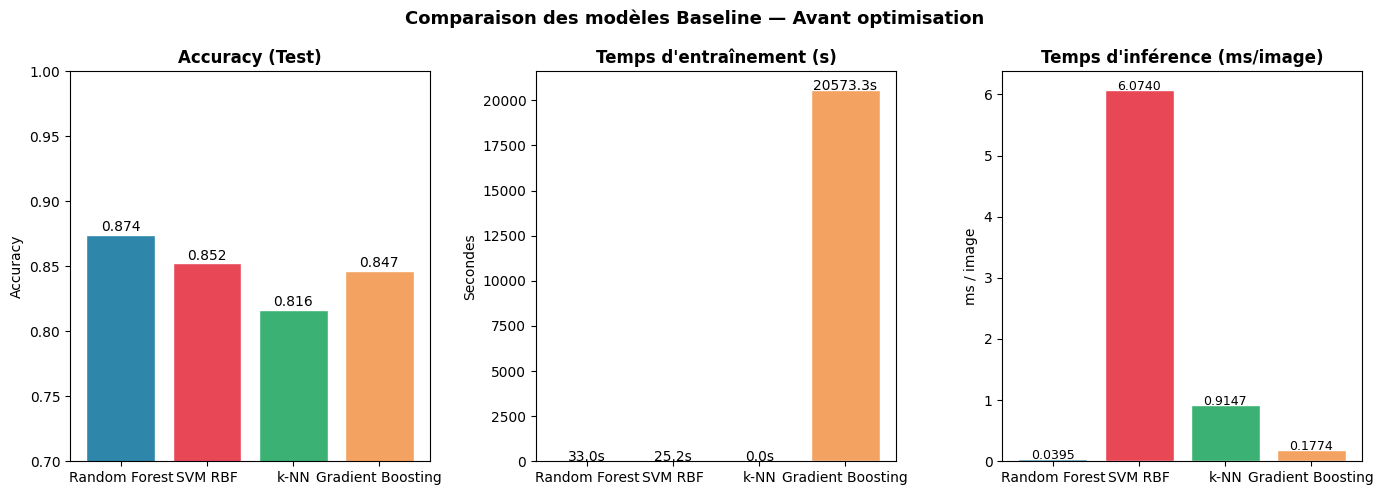

Graphique sauvegardé dans results/baseline_comparison_plot.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models = baseline_df["model_name"].tolist()
colors = ["#2E86AB", "#E84855", "#3BB273", "#F4A261"]

# Accuracy
axes[0].bar(models, baseline_df["accuracy"], color=colors, edgecolor="white")
axes[0].set_title("Accuracy (Test)", fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim([0.7, 1.0])
for i, v in enumerate(baseline_df["accuracy"]):
    axes[0].text(i, v + 0.003, f"{v:.3f}", ha="center", fontsize=10)

# Temps d'entraînement
axes[1].bar(models, baseline_df["training_time_s"], color=colors, edgecolor="white")
axes[1].set_title("Temps d'entraînement (s)", fontweight="bold")
axes[1].set_ylabel("Secondes")
for i, v in enumerate(baseline_df["training_time_s"]):
    axes[1].text(i, v + 0.5, f"{v:.1f}s", ha="center", fontsize=10)

# Inférence par image
axes[2].bar(models, baseline_df["inference_ms_per_sample"], color=colors, edgecolor="white")
axes[2].set_title("Temps d'inférence (ms/image)", fontweight="bold")
axes[2].set_ylabel("ms / image")
for i, v in enumerate(baseline_df["inference_ms_per_sample"]):
    axes[2].text(i, v + 0.0001, f"{v:.4f}", ha="center", fontsize=9)

plt.suptitle("Comparaison des modèles Baseline — Avant optimisation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("results/baseline_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé dans results/baseline_comparison_plot.png")

## 8. Matrice de confusion — Random Forest (meilleur baseline attendu)

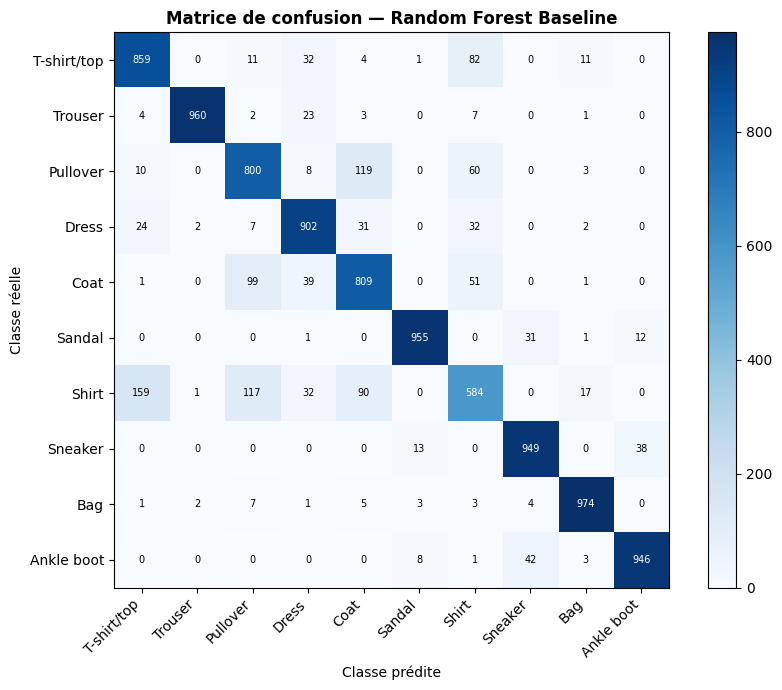


Rapport de classification — Random Forest:
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.86      0.83      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.77      0.80      0.78      1000
       Dress       0.87      0.90      0.89      1000
        Coat       0.76      0.81      0.79      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.71      0.58      0.64      1000
     Sneaker       0.92      0.95      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.95      0.95      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [10]:
y_pred_rf = rf_baseline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(9, 7))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.title("Matrice de confusion — Random Forest Baseline", fontweight="bold")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
for i in range(10):
    for j in range(10):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=7)
plt.tight_layout()
plt.show()

print("\nRapport de classification — Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=class_names))